In [ ]:
# ============================================================
# Leveraging AI for Predictive Cybersecurity Threat Intelligence
# CIC-IDS2018 Dataset - ML Pipeline
# Author: Vimalkanth Muthaliyappan Veerakumar (20025544)
# Dublin Business School - M.Sc. Cybersecurity, 2025
# ============================================================

# NOTE: If running on Google Colab, first mount your Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# Then update the dataset path in the next cell accordingly.


Mounted at /content/drive


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [ ]:
# Dataset path
# Local: '../data/CIC-IDS2018.csv'
# Google Colab: '/content/drive/MyDrive/CIC-IDS2018.csv'
df = pd.read_csv('../data/CIC-IDS2018.csv')


In [4]:
df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,02/03/2018 08:47:38,141385,9,7,553,3773.0,202,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,49684,6,02/03/2018 08:47:38,281,2,1,38,0.0,38,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,443,6,02/03/2018 08:47:40,279824,11,15,1086,10527.0,385,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,443,6,02/03/2018 08:47:40,132,2,0,0,0.0,0,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,443,6,02/03/2018 08:47:41,274016,9,13,1285,6141.0,517,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  float64
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

In [6]:
df.shape

(1048575, 80)

In [7]:
df.describe()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,...,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,8.423429e+03,8.049848e+00,1.151421e+07,5.887282e+00,6.983180e+00,3.920838e+02,5.271275e+03,2.104312e+02,8.249200e+00,5.461640e+01,...,2.044231e+00,1.745403e+01,1.229579e+05,6.130972e+04,1.905231e+05,8.305446e+04,4.781197e+06,1.064224e+05,4.863777e+06,4.677017e+06
std,1.516176e+04,4.432629e+00,3.012113e+07,8.903317e+01,2.129580e+02,2.159779e+03,3.088768e+05,2.669497e+02,2.094972e+01,5.762840e+01,...,1.392463e+01,5.179526e+00,2.083099e+06,1.261694e+06,2.761456e+06,1.759832e+06,1.741308e+07,1.462605e+06,1.756808e+07,1.733303e+07
min,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+01,6.000000e+00,5.160000e+02,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.389000e+03,6.000000e+00,1.124200e+04,3.000000e+00,1.000000e+00,6.300000e+01,1.290000e+02,4.600000e+01,0.000000e+00,4.000000e+01,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,8.080000e+03,6.000000e+00,2.210150e+06,7.000000e+00,5.000000e+00,3.650000e+02,5.820000e+02,3.260000e+02,0.000000e+00,1.086667e+02,...,3.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553400e+04,1.700000e+01,1.200000e+08,4.315900e+04,6.924100e+04,1.100627e+06,1.010000e+08,1.711000e+03,1.460000e+03,1.460000e+03,...,9.262000e+03,4.400000e+01,1.110000e+08,7.490000e+07,1.110000e+08,1.110000e+08,1.200000e+08,7.590000e+07,1.200000e+08,1.200000e+08


In [8]:
df.isnull().sum()

,0
Dst Port,0
Protocol,0
Timestamp,0
Flow Duration,0
Tot Fwd Pkts,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [9]:
df.duplicated().sum()

np.int64(5459)

In [10]:
df.drop_duplicates(inplace=True)

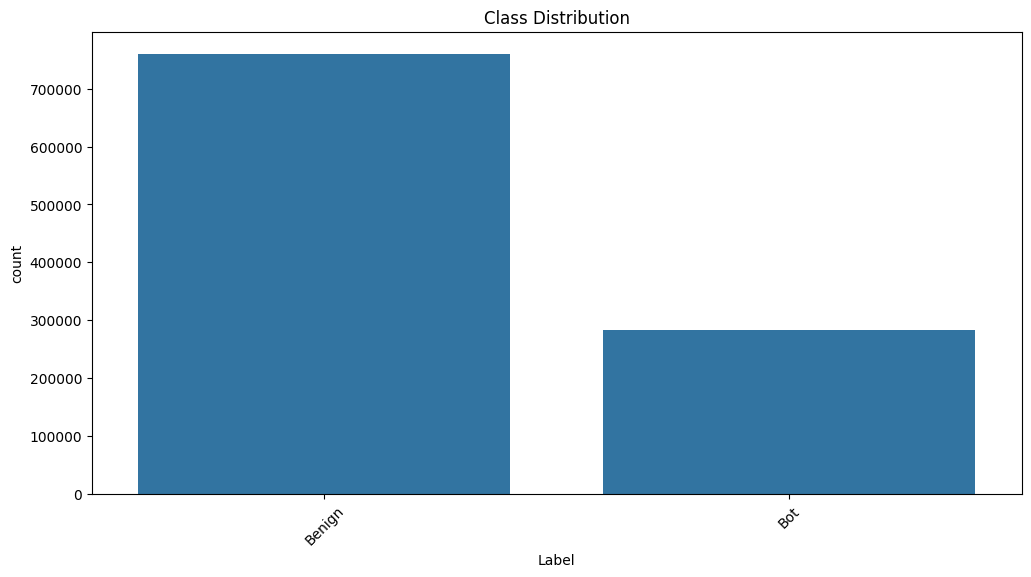

Label
Benign    760806
Bot       282310
Name: count, dtype: int64


In [11]:
# Target Class Distribution
plt.figure(figsize=(12,6))
sns.countplot(x='Label', data=df, order=df['Label'].value_counts().index)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

# Display class distribution counts
print(df['Label'].value_counts())

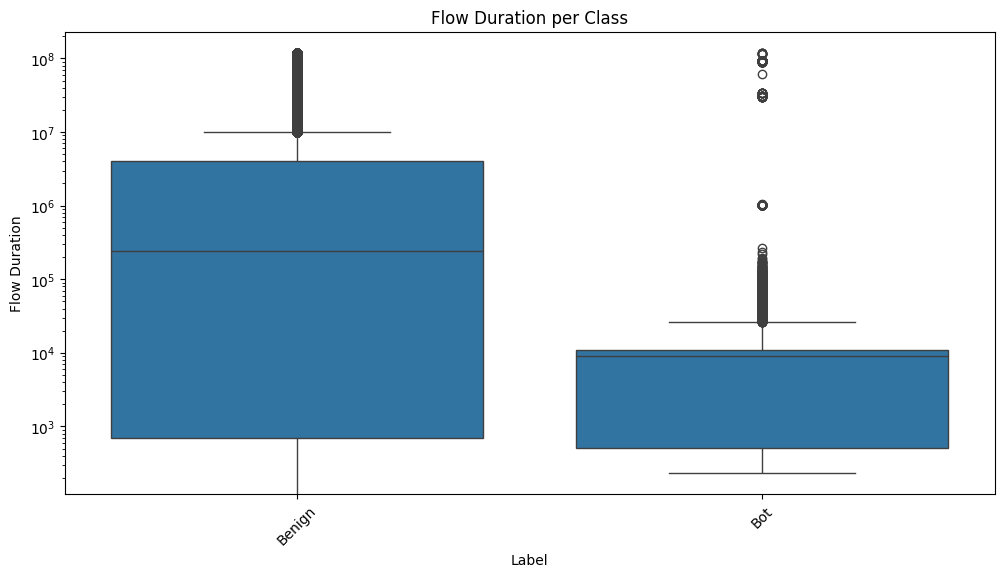

In [12]:
# Feature Distribution
plt.figure(figsize=(12,6))
sns.boxplot(x='Label', y='Flow Duration', data=df)
plt.title("Flow Duration per Class")
plt.xticks(rotation=45)
plt.yscale('log')
plt.show()


Protocol
6     827081
17    202653
0      13382
Name: count, dtype: int64
Dst Port
8080    277756
53      192857
3389    177448
80      108911
443      94796
445      41706
0        13382
5355      4579
137       1641
67         707
Name: count, dtype: int64


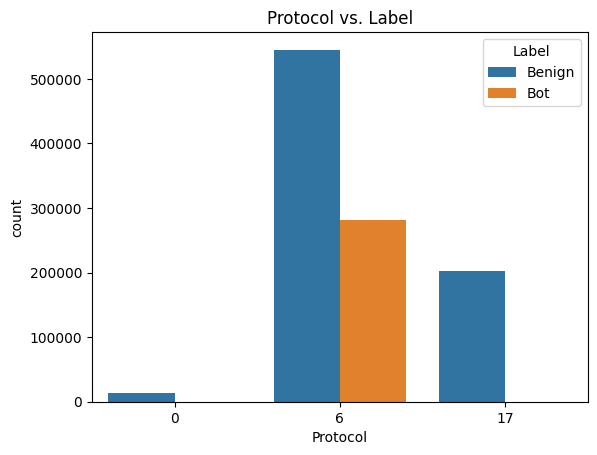

In [13]:
# Protocol and Port Analysis
# Protocols used
print(df['Protocol'].value_counts())

# Top 10 destination ports
print(df['Dst Port'].value_counts().head(10))

# Protocol vs. Label
sns.countplot(data=df, x='Protocol', hue='Label')
plt.title("Protocol vs. Label")
plt.show()


In [14]:
# Statistical Outlier Check
from scipy.stats import zscore

numeric_df = df.select_dtypes(include=['float64', 'int64']).copy()
z_scores = zscore(numeric_df)
outliers = (abs(z_scores) > 3).sum(axis=1)
print(f"Rows with potential outliers (z > 3): {(outliers > 0).sum()} / {df.shape[0]}")


/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:1158: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


Rows with potential outliers (z > 3): 243928 / 1043116


/tmp/ipython-input-3915081805.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_var.values, y=top_var.index, palette="viridis")


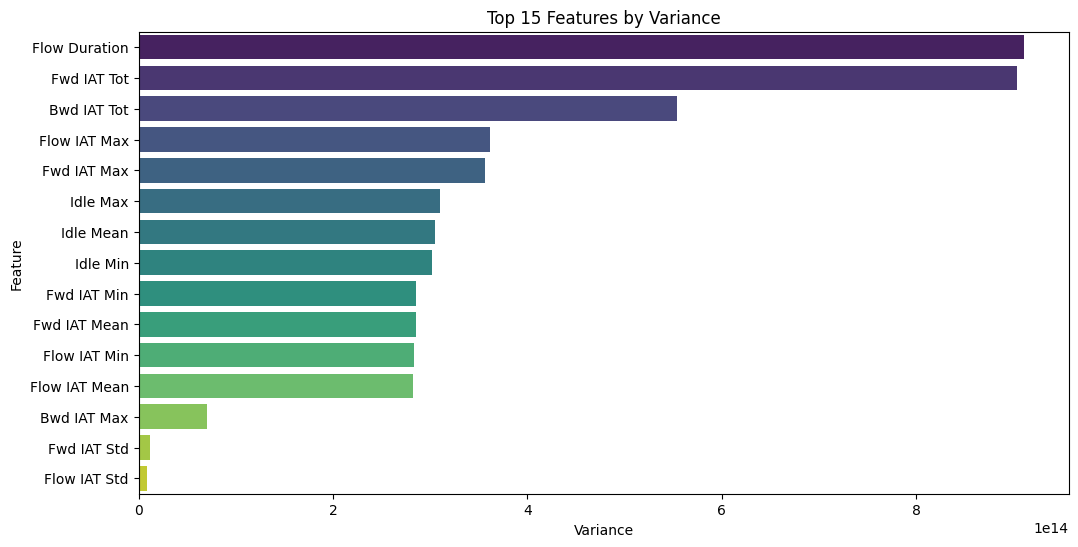

In [15]:
# Top Features by Variance

variances = df.select_dtypes(include=['float64', 'int64']).var().sort_values(ascending=False)
top_var = variances.head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_var.values, y=top_var.index, palette="viridis")
plt.title("Top 15 Features by Variance")
plt.xlabel("Variance")
plt.ylabel("Feature")
plt.show()


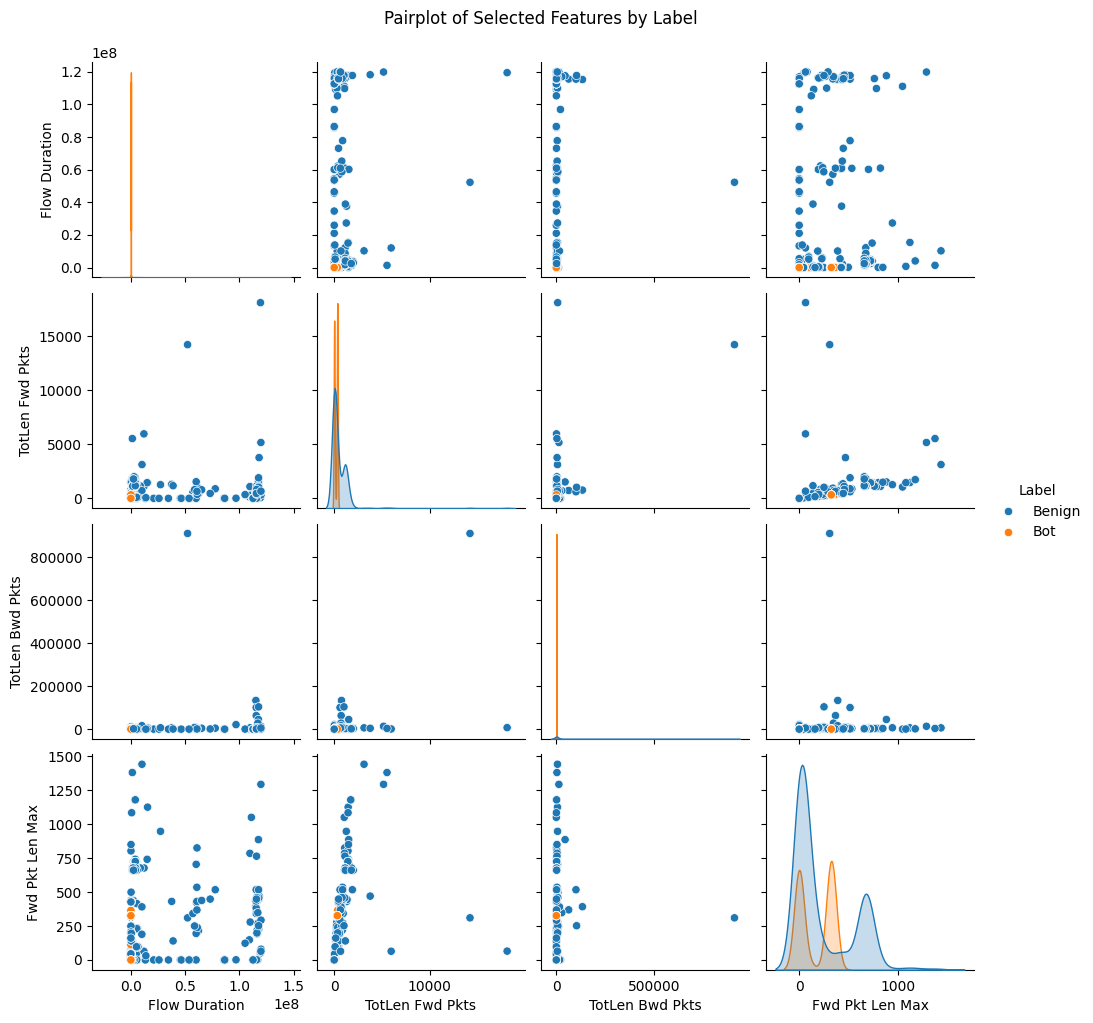

In [16]:
# Pairplot of Key Features by Label
sample_df = df.sample(n=1000, random_state=42)  # sample for performance
features = ['Flow Duration', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max']

sns.pairplot(sample_df[features + ['Label']], hue='Label', diag_kind='kde')
plt.suptitle("Pairplot of Selected Features by Label", y=1.02)
plt.show()

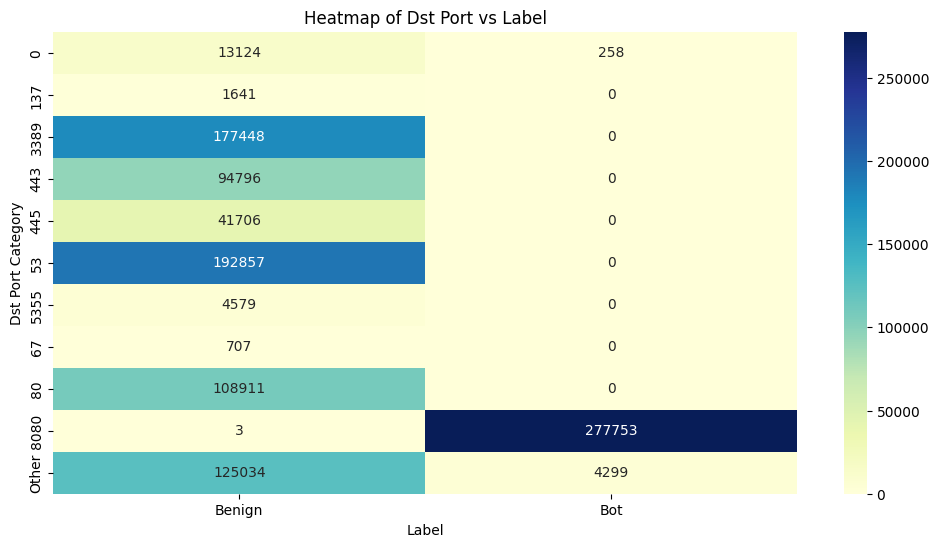

In [17]:
# Heatmap of Categorical Features vs Target
# Binning destination ports into top 10 and 'Other'
df['Dst Port Category'] = df['Dst Port'].astype(str)
top_ports = df['Dst Port Category'].value_counts().nlargest(10).index
df['Dst Port Category'] = df['Dst Port Category'].apply(lambda x: x if x in top_ports else 'Other')

# Cross-tab heatmap
cross_tab = pd.crosstab(df['Dst Port Category'], df['Label'])

plt.figure(figsize=(12, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Heatmap of Dst Port vs Label")
plt.xlabel("Label")
plt.ylabel("Dst Port Category")
plt.show()

# **Data Preprocessing**

In [18]:
# Encoding categorical columns
categorical_cols = ['Protocol', 'Dst Port Category']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Display the first few rows after encoding
print(df.head())

   Dst Port  Protocol            Timestamp  Flow Duration  Tot Fwd Pkts  \
0       443         1  02/03/2018 08:47:38         141385             9   
1     49684         1  02/03/2018 08:47:38            281             2   
2       443         1  02/03/2018 08:47:40         279824            11   
3       443         1  02/03/2018 08:47:40            132             2   
4       443         1  02/03/2018 08:47:41         274016             9   

   Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
0             7              553           3773.0              202   
1             1               38              0.0               38   
2            15             1086          10527.0              385   
3             0                0              0.0                0   
4            13             1285           6141.0              517   

   Fwd Pkt Len Min  ...  Active Mean  Active Std  Active Max  Active Min  \
0                0  ...          0.0         0.0    

In [19]:
# Train-Test Split

import pandas as pd
# Separate features (X) and target (y)
X = df.drop('Label', axis=1)
y = df['Label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (834492, 80)
Shape of y_train: (834492,)
Shape of X_test: (208624, 80)
Shape of y_test: (208624,)


In [20]:
import numpy as np
from imblearn.over_sampling import SMOTE

# Drop 'Timestamp' and other non-numeric/categorical columns if still present
X_cleaned = X_train.drop(columns=['Timestamp'], errors='ignore')

# Replace inf/-inf with NaN
X_cleaned = X_cleaned.replace([np.inf, -np.inf], np.nan)

# Fill remaining NaN with column means
X_cleaned = X_cleaned.fillna(X_cleaned.mean())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_cleaned, y_train)

# Check output
print("SMOTE applied successfully!")
print("New class distribution:\n", pd.Series(y_train_smote).value_counts())


SMOTE applied successfully!
New class distribution:
 Label
Bot       608644
Benign    608644
Name: count, dtype: int64


# **Random Forest**

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [22]:
# Clean X_test same as X_train
X_test_cleaned = X_test.drop(columns=['Timestamp'], errors='ignore')
X_test_cleaned = X_test_cleaned.replace([np.inf, -np.inf], np.nan)
X_test_cleaned = X_test_cleaned.fillna(X_test_cleaned.mean())


In [23]:
# Initialize Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test_cleaned)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    152162
         Bot       1.00      1.00      1.00     56462

    accuracy                           1.00    208624
   macro avg       1.00      1.00      1.00    208624
weighted avg       1.00      1.00      1.00    208624



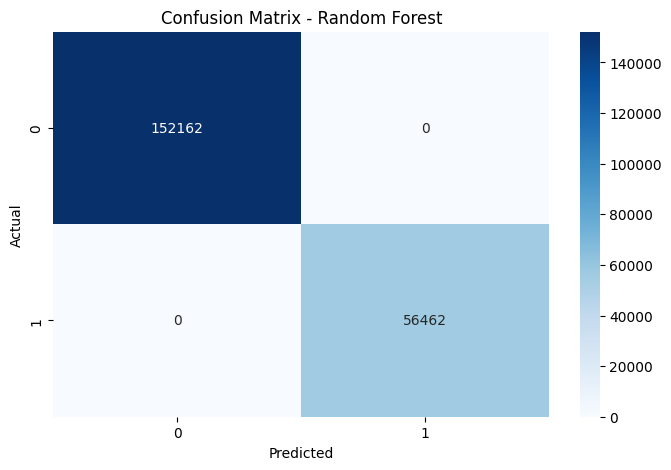

In [24]:
# Plot Confusion Matrix
def plot_conf_matrix(y_true, y_pred, title):
    plt.figure(figsize=(8, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_conf_matrix(y_test, y_pred_rf, "Random Forest")

# **XGBoost**

In [25]:
# Initialize Model

# Encode target variable
le = LabelEncoder()
y_train_smote_encoded = le.fit_transform(y_train_smote)
y_test_encoded = le.transform(y_test)


xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_smote, y_train_smote_encoded)
y_pred_xgb = xgb.predict(X_test_cleaned)

print("XGBoost Classification Report:")
print(classification_report(y_test_encoded, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:42:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    152162
           1       1.00      1.00      1.00     56462

    accuracy                           1.00    208624
   macro avg       1.00      1.00      1.00    208624
weighted avg       1.00      1.00      1.00    208624



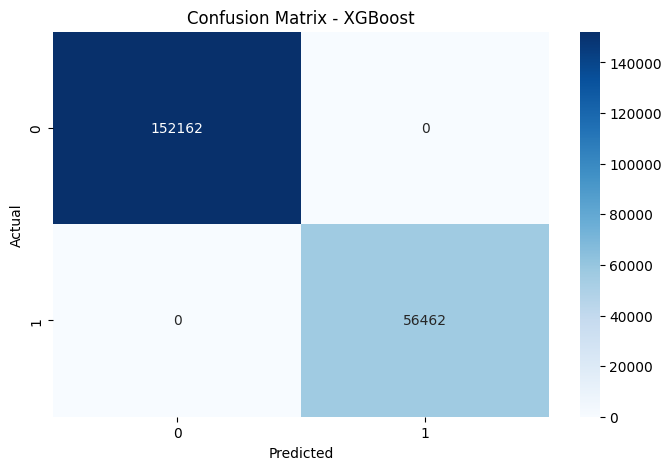

In [26]:
# Plot Confusion Matrix
def plot_conf_matrix(y_true, y_pred, title):
    plt.figure(figsize=(8, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_conf_matrix(y_test_encoded, y_pred_xgb, "XGBoost")

# **SVM**

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    152162
           1       0.88      1.00      0.93     56462

    accuracy                           0.96    208624
   macro avg       0.94      0.97      0.95    208624
weighted avg       0.97      0.96      0.96    208624



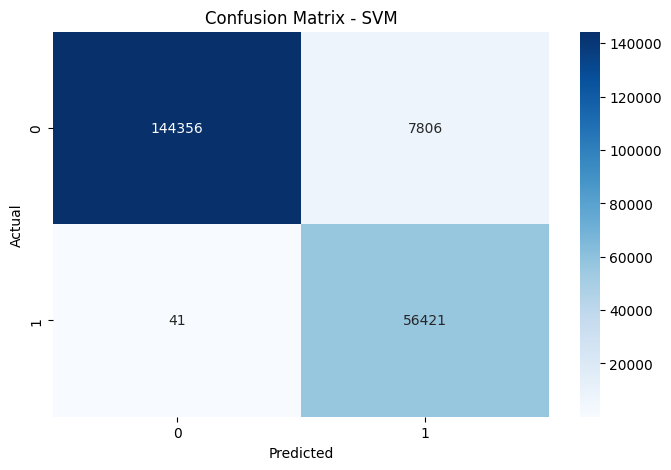

In [27]:
# Initialize model
from sklearn.svm import LinearSVC


svm_model = LinearSVC(random_state=42, dual=False) # Set dual=False for n_samples > n_features
svm_model.fit(X_train_smote, y_train_smote_encoded)

# Predict and Evaluate
y_pred_svm = svm_model.predict(X_test_cleaned)

print("SVM Classification Report:")
print(classification_report(y_test_encoded, y_pred_svm))

# Plot Confusion Matrix for SVM
plot_conf_matrix(y_test_encoded, y_pred_svm, "SVM")

# **Logistic Regression**

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    152162
           1       0.99      1.00      0.99     56462

    accuracy                           1.00    208624
   macro avg       0.99      1.00      1.00    208624
weighted avg       1.00      1.00      1.00    208624



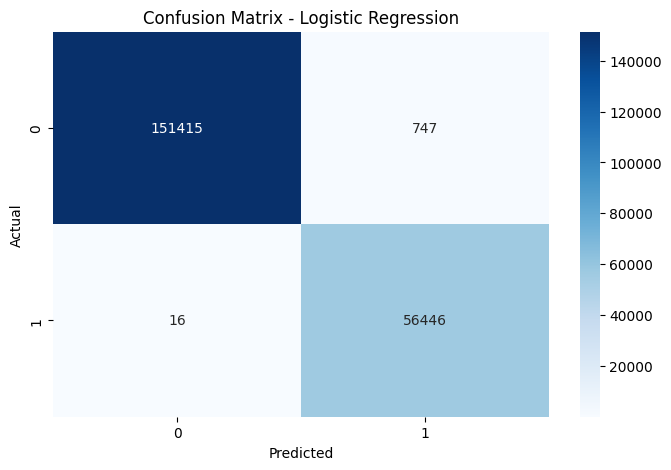

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# Initialize and Train Logistic Regression Model
# Increased max_iter to ensure convergence
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Scale the data
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_cleaned_scaled = scaler.transform(X_test_cleaned)

lr_model.fit(X_train_smote_scaled, y_train_smote_encoded)

# Predict and Evaluate Logistic Regression Model
y_pred_lr = lr_model.predict(X_test_cleaned_scaled)

print("Logistic Regression Classification Report:")
print(classification_report(y_test_encoded, y_pred_lr))

# Plot Confusion Matrix for Logistic Regression
plot_conf_matrix(y_test_encoded, y_pred_lr, "Logistic Regression")

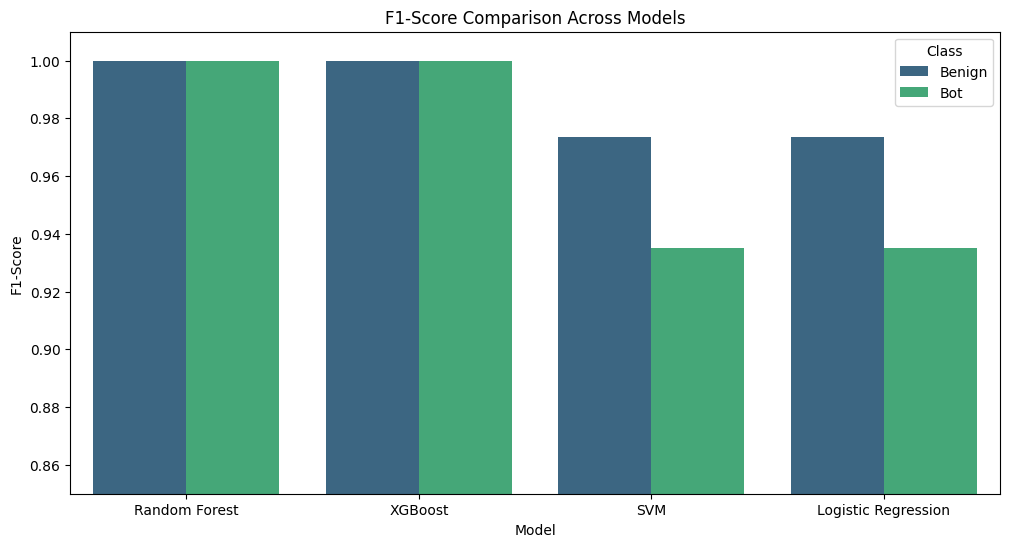

In [35]:
# Collect evaluation results
results = []

# Random Forest results
results.append({'Model': 'Random Forest', 'Class': 'Benign', 'F1-Score': report_rf['Benign']['f1-score']})
results.append({'Model': 'Random Forest', 'Class': 'Bot', 'F1-Score': report_rf['Bot']['f1-score']})


# XGBoost results
results.append({'Model': 'XGBoost', 'Class': 'Benign', 'F1-Score': report_xgb['0']['f1-score']})
results.append({'Model': 'XGBoost', 'Class': 'Bot', 'F1-Score': report_xgb['1']['f1-score']})

# SVM results
results.append({'Model': 'SVM', 'Class': 'Benign', 'F1-Score': report_svm['0']['f1-score']})
results.append({'Model': 'SVM', 'Class': 'Bot', 'F1-Score': report_svm['1']['f1-score']})

# Logistic Regression results
results.append({'Model': 'Logistic Regression', 'Class': 'Benign', 'F1-Score': report_lr['0']['f1-score']})
results.append({'Model': 'Logistic Regression', 'Class': 'Bot', 'F1-Score': report_lr['1']['f1-score']})


results_df = pd.DataFrame(results)

# Plot the F1 comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='F1-Score', hue='Class', data=results_df, palette='viridis')
plt.title('F1-Score Comparison Across Models')
plt.ylabel('F1-Score')
plt.ylim(0.85, 1.01) # Set y-axis limit for better comparison of high scores
plt.show()